In [1]:
from itertools import groupby

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from conda_index.postgres.model import columns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
df = pd.DataFrame({
    'booking_id': range(8001, 8051),
    'hotel_type': np.random.choice(['Resort', 'City', None], 50),
    'arrival_date': pd.date_range('2026-01-01', periods=50, freq='D'), # 50天连续日期
    'nights': np.random.randint(1, 10, 50).astype(float),
    'room_price': np.random.rand(50) * 800,
    'discount': np.random.choice([0.1, 0.2, 0.3, None], 50),
    'is_canceled': np.random.choice([0, 1], 50), # 0未取消，1已取消
    'customer_type': np.random.choice(['Member', 'Transient'], 50)
})
# 故意挖空值
df.loc[0:5, 'room_price'] = np.nan
df.loc[10:15, 'nights'] = np.nan
df.loc[20:23, 'discount'] = np.nan
df.loc[30:33, 'hotel_type'] = np.nan
print("酒店数据准备完毕！开始手打下方代码。")

酒店数据准备完毕！开始手打下方代码。


In [2]:
df['room_price']=df['room_price'].fillna(df['room_price'].median())
df['nights']=df['nights'].fillna(df['nights'].mean())
df['discount']=df['discount'].fillna(df['discount'].mean())
df['hotel_type']=df['hotel_type'].fillna(df['hotel_type'].mode()[0])
df['total_cost']=df['room_price']*df['nights']*(1-df['discount'])
df['arrival_date']=pd.to_datetime(df['arrival_date'])
df['month']=df['arrival_date'].dt.month
df['weekday']=df['arrival_date'].dt.dayofweek
df=pd.get_dummies(df,columns=['customer_type'],drop_first=True)
df.drop(columns=['booking_id'], inplace=True)

In [3]:
print(df.groupby('hotel_type')['is_canceled'].mean())
month_stats=df.groupby(['hotel_type','month'])['total_cost'].sum().reset_index()
print(month_stats)
df_summary=df.groupby('hotel_type').agg({
    'total_cost':'sum',
    'nights':'mean',
    'is_canceled':'count',
}).reset_index()
print(df_summary)

hotel_type
City      0.416667
Resort    0.500000
Name: is_canceled, dtype: float64
  hotel_type  month    total_cost
0       City      1   8873.470425
1       City      2   7137.004254
2     Resort      1   45542.36026
3     Resort      2  22574.105881
  hotel_type    total_cost    nights  is_canceled
0       City  16010.474679  5.378788           12
1     Resort  68116.466141  5.598086           38


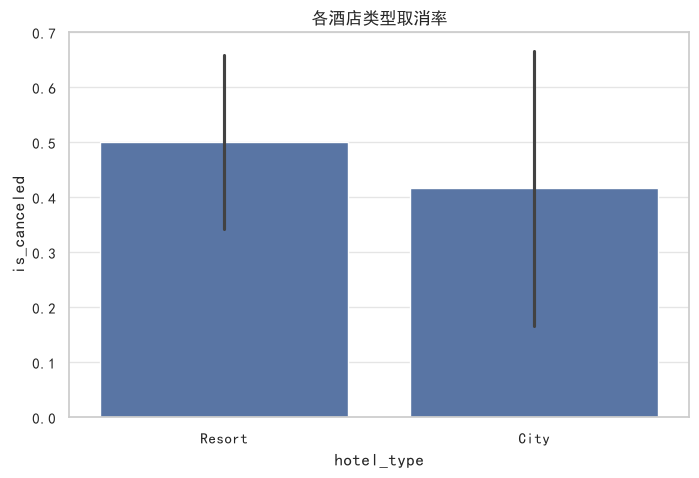

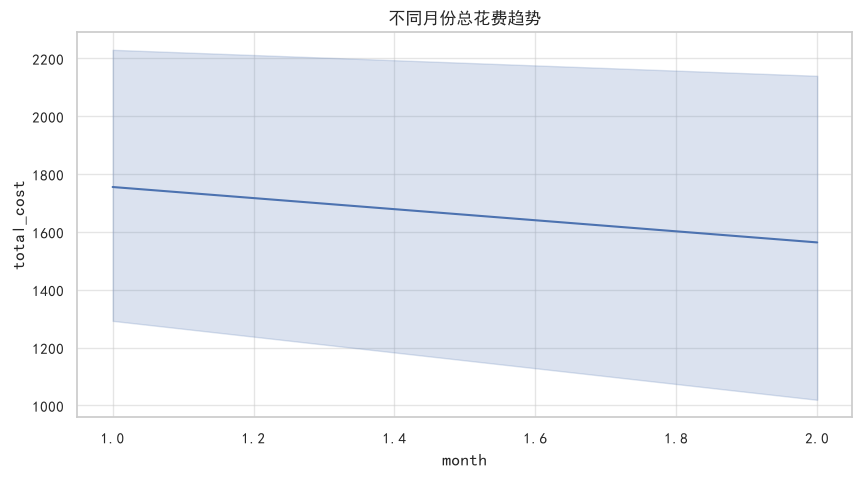

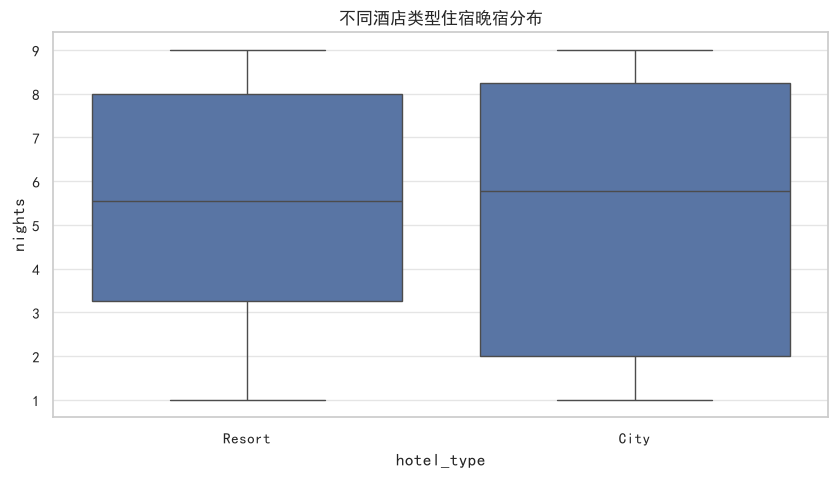

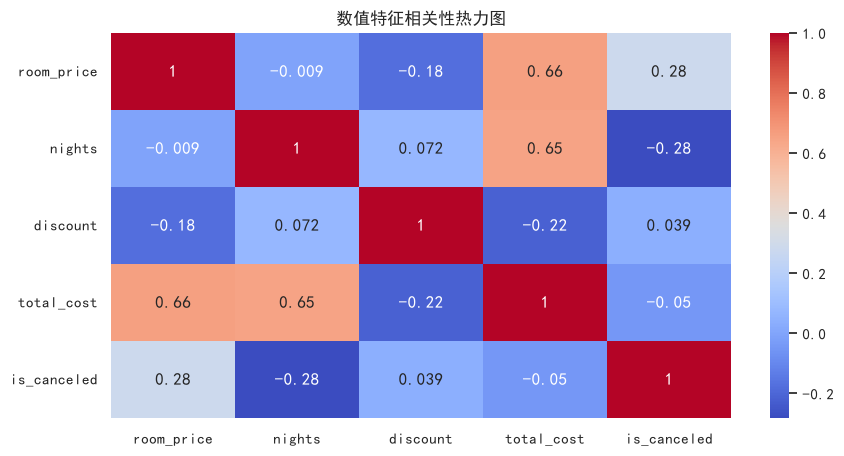

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='hotel_type',y='is_canceled')
plt.title("各酒店类型取消率")
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=df,x='month',y='total_cost')
plt.title("不同月份总花费趋势")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='hotel_type',y='nights')
plt.title("不同酒店类型住宿晚宿分布")
plt.show()

num_cols=df[['room_price','nights','discount','total_cost','is_canceled']]
plt.figure(figsize=(10,5))
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("数值特征相关性热力图")
plt.show()

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
df = pd.DataFrame({
    'user_id': range(10001, 10051),
    'song_id': np.random.randint(100, 200, 50),
    'genre': np.random.choice(['Pop', 'Rock', 'Jazz', None], 50),
    'listen_time': np.random.rand(50) * 300,   # 收听时长(秒)
    'skip_rate': np.random.rand(50),           # 跳过率(0-1)
    'is_premium': np.random.choice(['Yes', 'No'], 50),
    'listen_date': pd.date_range('2026-05-01', periods=50, freq='h')
})
# 挖空值
df.loc[0:5, 'listen_time'] = np.nan
df.loc[10:13, 'skip_rate'] = np.nan
df.loc[20:25, 'genre'] = np.nan
print("音乐数据准备完毕！请开始独立完成下方任务。")

音乐数据准备完毕！请开始独立完成下方任务。


In [16]:
df[['listen_time','skip_rate']]=df[['listen_time','skip_rate']].fillna(df[['listen_time','skip_rate']].mean())
df['genre']=df['genre'].fillna(df['genre'].mode()[0])
df['valid_time'] = df['listen_time'] * (1 - df['skip_rate'])
df['hour']=df['listen_date'].dt.hour
df=pd.get_dummies(df,columns=['is_premium'],drop_first=True)
df.drop(columns=['user_id','song_id'], inplace=True)

In [19]:
print(df.groupby('genre')['valid_time'].mean())
print(df.groupby('genre')['valid_time'].sum())
avg_skip_rate=df.groupby(['genre','is_premium_Yes'])['skip_rate'].mean().reset_index()
df_genre=df.groupby('genre').agg({
    'valid_time':'mean',
    'skip_rate':'max',
    'hour':'count',
}).reset_index()



genre
Jazz    79.465578
Pop     88.800106
Rock    82.567042
Name: valid_time, dtype: float64
genre
Jazz     556.259045
Pop      444.000529
Rock    3137.547584
Name: valid_time, dtype: float64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
df = pd.DataFrame({
    'order_id': range(5001, 5061),
    'category': np.random.choice(['Clothing', 'Electronics', 'Home', None], 60),
    'price': np.random.rand(60) * 1000,
    'return_days': np.random.randint(1, 30, 60).astype(float),
    'return_reason': np.random.choice(['Size', 'Quality', 'Wrong Item', None], 60),
    'is_vip': np.random.choice(['Yes', 'No'], 60),
    'order_date': pd.date_range('2026-01-01', periods=60, freq='D')
})
# 故意挖空值
df.loc[0:5, 'price'] = np.nan
df.loc[10:15, 'return_days'] = np.nan
df.loc[20:25, 'return_reason'] = np.nan

print("电商退货数据准备完毕！请开始独立完成下方任务。")

电商退货数据准备完毕！请开始独立完成下方任务。


In [15]:
df['price']=df['price'].fillna(df['price'].median())
df['return_days']=df['return_days'].fillna(df['return_days'].mean())
df['return_reason']=df['return_reason'].fillna(df['return_reason'].mode()[0])
df['refund_amount']=df['price']*0.9
df['month']=df['order_date'].dt.month
df=pd.get_dummies(df,columns=['is_vip'],drop_first=True)
df.drop(columns=['order_id'], inplace=True)

In [16]:
print(df.groupby('return_reason')['price'].mean())
print(df.groupby('return_reason')['price'].sum())
print(df.groupby(['return_reason','is_vip_Yes'])['return_days'].mean().reset_index())
df_drfw=df.groupby('category').agg({
    'refund_amount':'mean',
    'return_days':'max'
}).reset_index()


return_reason
Quality       470.985474
Size          481.725173
Wrong Item    462.960164
Name: price, dtype: float64
return_reason
Quality        6593.796633
Size          16378.655889
Wrong Item     5555.521965
Name: price, dtype: float64
  return_reason  is_vip_Yes  return_days
0       Quality       False    18.103175
1       Quality        True    18.000000
2          Size       False    14.362963
3          Size        True    15.339181
4    Wrong Item       False    17.465278
5    Wrong Item        True    11.000000


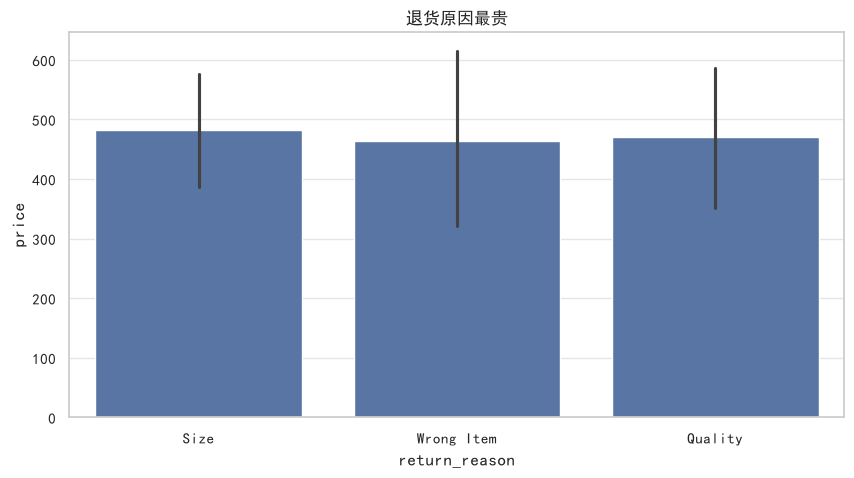

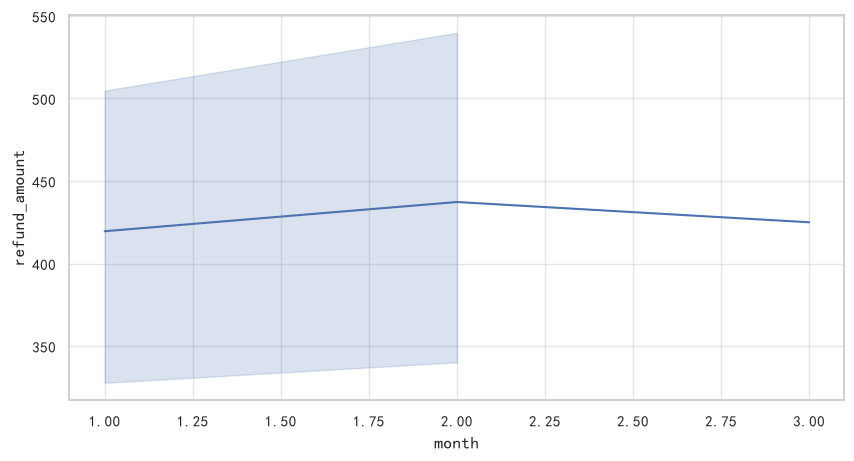

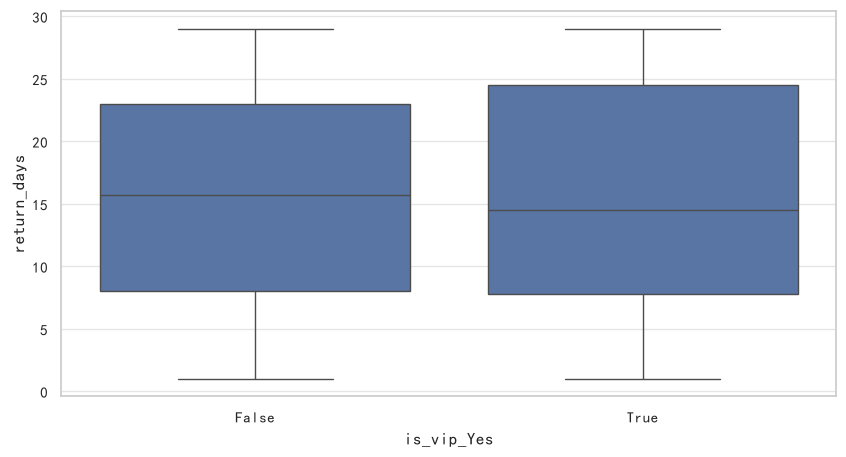

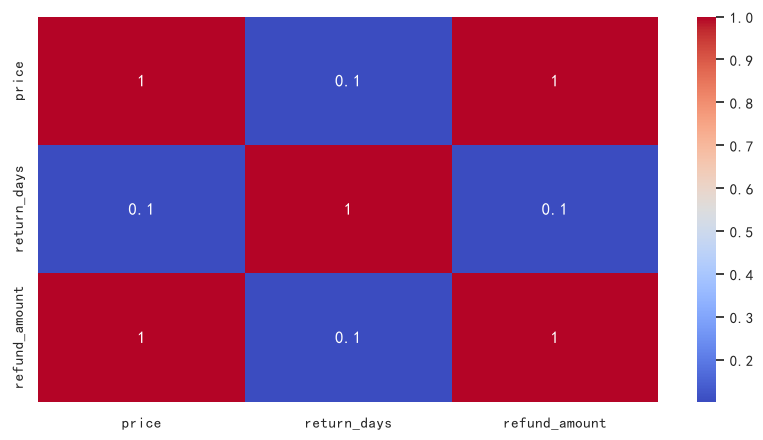

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x='return_reason',y='price')
plt.title("退货原因最贵")
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=df,x='month',y='refund_amount')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='is_vip_Yes',y='return_days')
plt.show()

num_cols=df[['price','return_days','refund_amount']]
plt.figure(figsize=(10,5))
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.show()

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
df = pd.DataFrame({
    'patient_id': range(2001, 2051),
    'department': np.random.choice(['内科', '外科', '儿科', None], 50),
    'doctor_level': np.random.choice(['专家', '普通'], 50),
    'wait_time': np.random.randint(10, 120, 50).astype(float),
    'treatment_fee': np.random.rand(50) * 500,
    'is_insured': np.random.choice(['是', '否'], 50),
    'visit_date': pd.date_range('2026-03-01', periods=50, freq='D')
})
# 故意挖空值
df.loc[0:5, 'wait_time'] = np.nan
df.loc[10:15, 'treatment_fee'] = np.nan
df.loc[20:25, 'department'] = np.nan

print("医院门诊数据准备完毕！请开始独立完成下方任务。")

医院门诊数据准备完毕！请开始独立完成下方任务。


In [31]:
df['wait_time']=df['wait_time'].fillna(df['wait_time'].mean())
df['treatment_fee']=df['treatment_fee'].fillna(df['treatment_fee'].median())
df['department']=df['department'].fillna(df['department'].mode()[0])
df['total_cost']=df['treatment_fee']*1.2
df['day_of_week']=df['visit_date'].dt.day_of_week
df=pd.get_dummies(df,columns=['doctor_level'],drop_first=True)
df.drop(columns=['patient_id'],inplace=True)

In [33]:
print(df.groupby('department')['treatment_fee'].mean())
print(df.groupby(['department','is_insured'])['wait_time'].mean().reset_index())
df_fsae=df.groupby('department').agg({
    'total_cost':'mean',
    'wait_time':'max',
}).reset_index()
#df_summary['患者人数'] = df.groupby('department').size().values
#print(df_summary)


department
儿科    228.451503
内科    286.117919
外科    206.420661
Name: treatment_fee, dtype: float64
  department is_insured  wait_time
0         儿科          否  62.489234
1         儿科          是  55.061688
2         内科          否  68.333333
3         内科          是  78.571970
4         外科          否  89.000000
5         外科          是  82.750000


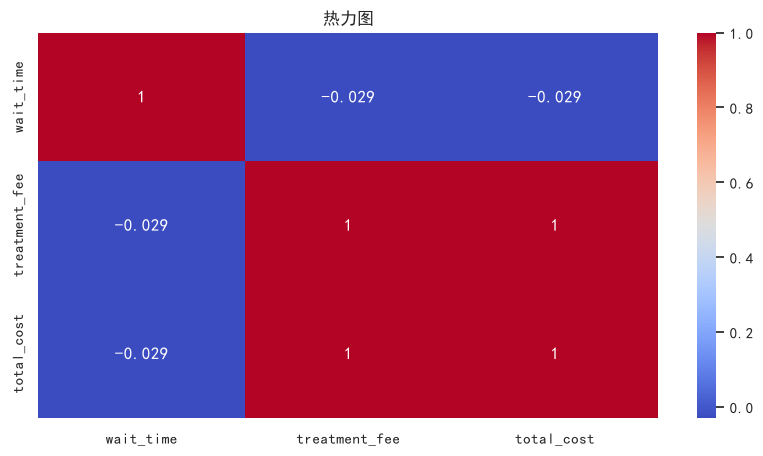

In [37]:
num_cols=df[['wait_time','treatment_fee','total_cost']]
plt.figure(figsize=(10,5))
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("热力图")
plt.show()

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
df = pd.DataFrame({
    'device_id': range(3001, 3051),
    'device_type': np.random.choice(['AC', 'Light', 'Fridge', None], 50),
    'temp': np.random.rand(50) * 15 + 20,     # 温度
    'humidity': np.random.rand(50) * 40 + 30,  # 湿度
    'power_usage': np.random.rand(50) * 10,    # 耗电量(kWh)
    'is_peak_hour': np.random.choice(['Yes', 'No'], 50),
    'record_time': pd.date_range('2026-07-01', periods=50, freq='h')
})
# 故意挖空值
df.loc[0:5, 'temp'] = np.nan
df.loc[10:15, 'humidity'] = np.nan
df.loc[20:25, 'power_usage'] = np.nan
df.loc[30:33, 'device_type'] = np.nan

print("智能家居数据准备完毕！请开始独立完成下方任务。")

智能家居数据准备完毕！请开始独立完成下方任务。


In [45]:
df['temp']=df['temp'].fillna(df['temp'].mean())
df['humidity']=df['humidity'].fillna(df['humidity'].median())
df['power_usage']=df['power_usage'].fillna(df['power_usage'].mean())
df['device_type']=df['device_type'].fillna(df['device_type'].mode()[0])
df['cost']=df['power_usage']*0.6
df['hour']=df['record_time'].dt.hour
df=pd.get_dummies(df,columns=['is_peak_hour'],drop_first=True)
df.drop(columns=['device_id'],inplace=True)




In [47]:
print(df.groupby('device_type')['power_usage'].sum())
print(df.groupby('device_type')['cost'].mean())
print(df.groupby('hour')['power_usage'].mean().reset_index())
df_wgds=df.groupby('device_type').agg({
    'power_usage':'max',
    'temp':'mean',
    'cost':'count',
}).reset_index()

device_type
AC         41.716516
Fridge    147.769907
Light      45.220090
Name: power_usage, dtype: float64
device_type
AC        3.128739
Fridge    2.770686
Light     2.713205
Name: cost, dtype: float64
    hour  power_usage
0      0     3.743389
1      1     6.442002
2      2     5.501462
3      3     0.759235
4      4     5.001000
5      5     7.015307
6      6     2.320815
7      7     3.960005
8      8     5.496174
9      9     5.902736
10    10     5.257096
11    11     4.432869
12    12     6.676624
13    13     4.985797
14    14     7.537784
15    15     5.263685
16    16     5.435424
17    17     4.090143
18    18     2.436984
19    19     1.628078
20    20     5.301530
21    21     5.734887
22    22     2.430004
23    23     4.907530


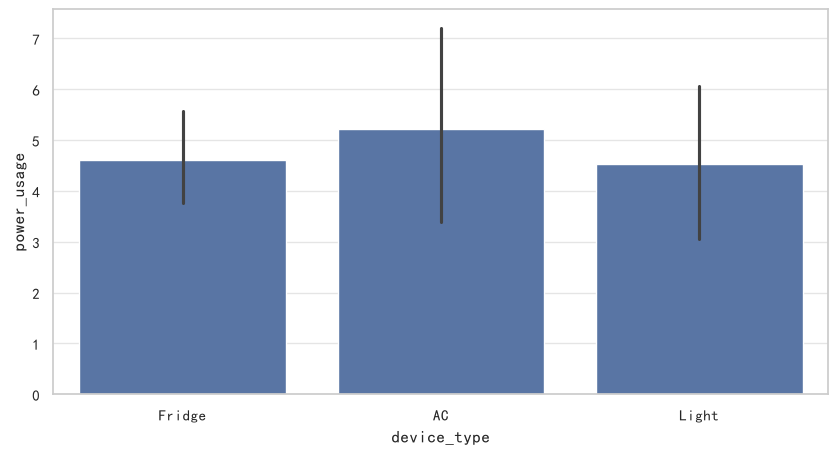

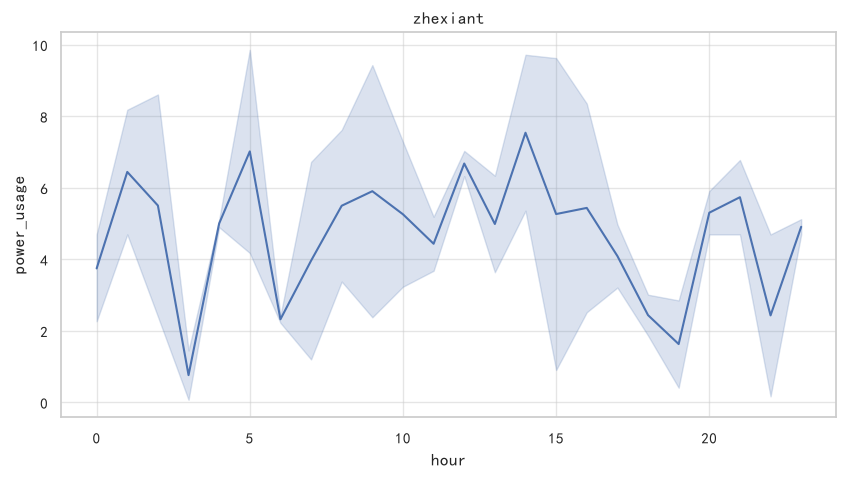

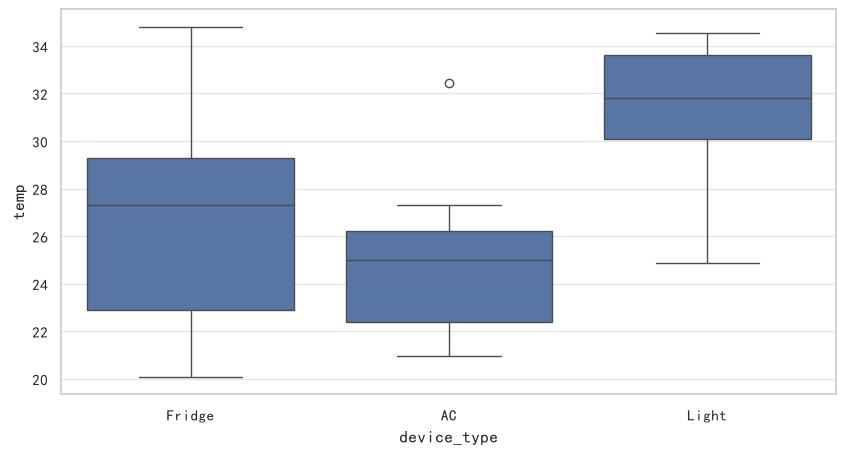

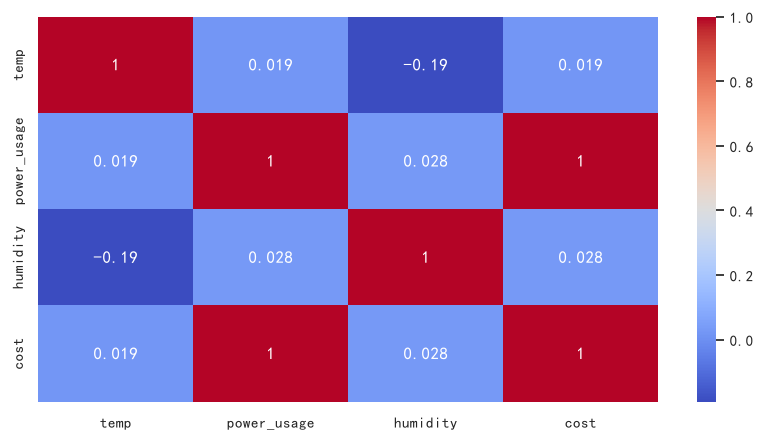

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [48]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x='device_type',y='power_usage')
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=df,x='hour',y='power_usage')
plt.title("zhexiant")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='device_type',y='temp')
plt.show()

num_cols=df[['temp','power_usage','humidity','cost']]
plt.figure(figsize=(10,5))
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.show()
plt.figure(figsize=(10,5))

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
df = pd.DataFrame({
    'live_id': range(4001, 4061),
    'category': np.random.choice(['美妆', '服饰', '食品', '数码', None], 60),
    'streamer_gender': np.random.choice(['男', '女'], 60),
    'viewers': np.random.randint(1000, 50000, 60).astype(float),     # 观看人数
    'sales_amount': np.random.rand(60) * 100000,                     # 销售额
    'return_rate': np.random.rand(60) * 0.4,                         # 退货率(0-0.4)
    'is_prime_time': np.random.choice(['Yes', 'No'], 60),            # 是否黄金时段
    'live_date': pd.date_range('2026-08-01', periods=60, freq='D')   # 直播日期
})

# 故意挖空值
df.loc[0:5, 'viewers'] = np.nan
df.loc[10:15, 'sales_amount'] = np.nan
df.loc[20:25, 'return_rate'] = np.nan
df.loc[30:33, 'category'] = np.nan

print("直播带货数据准备完毕！请开始独立完成下方任务。")

直播带货数据准备完毕！请开始独立完成下方任务。


In [26]:
df['viewers']=df['viewers'].fillna(df['viewers'].mean())
df['sales_amount']=df['sales_amount'].fillna(df['sales_amount'].median())
df['category']=df['category'].fillna(df['category'].mode()[0])
df['actual_sales']=df['sales_amount']*(1-df['return_rate'])
df['month']=df['live_date'].dt.month
df['day_of_week']=df['live_date'].dt.day_of_week
df=pd.get_dummies(df,columns=['is_prime_time'],drop_first=True)
df.drop(columns=['live_id'],inplace=True)

In [27]:
print(df.groupby('category')['actual_sales'].mean())
print(df.groupby(['category','is_prime_time_Yes'])['viewers'].mean().reset_index())
df_wgsw=df.groupby('category').agg({
    'actual_sales':'sum',
    'return_rate':'max',
   # 'actual_sales':'count',
}).reset_index()

category
数码    32638.308974
服饰    45392.576124
美妆    38629.705576
食品    41646.658195
Name: actual_sales, dtype: float64
  category  is_prime_time_Yes       viewers
0       数码              False  31397.259259
1       数码               True  20120.820513
2       服饰              False  22636.305556
3       服饰               True  29964.000000
4       美妆              False  13257.500000
5       美妆               True  29036.400000
6       食品              False  30738.458333
7       食品               True  29062.666667


['category', 'streamer_gender', 'viewers', 'sales_amount', 'return_rate', 'live_date', 'actual_sales', 'month', 'day_of_week', 'is_prime_time_Yes']


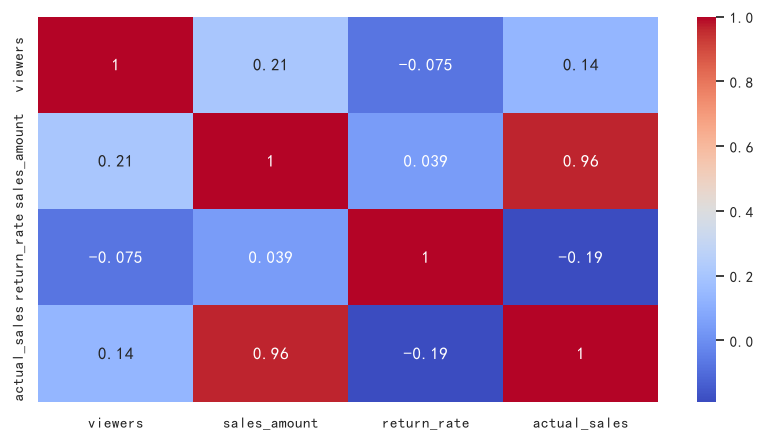

In [30]:
print(df.columns.tolist())
num_cols=df[['viewers','sales_amount','return_rate','actual_sales']]
plt.figure(figsize=(10,5))
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.show()

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
# 表1：员工基础信息
df_emp = pd.DataFrame({
    'emp_id': [1, 2, 3, 4, 5, 6],
    'name': ['张三', '李四', '王五', '赵六', '孙七', '周八'],
    'dept': ['IT', 'HR', 'IT', 'HR', 'Finance', 'IT'],
    'base_salary': [8000, 6000, 12000, 7000, 9000, 15000]
})

# 表2：考勤记录（一员工多天记录，故意只有 5 条，缺了周八的记录）
df_att = pd.DataFrame({
    'emp_id': [1, 1, 2, 3, 4, 5, 6],
    'date': pd.date_range('2026-09-01', periods=7, freq='D'),
    'overtime_hours': [2, 0, 1, 3, 0, 2, 4]
})
print("两张表已准备好！")

两张表已准备好！


In [33]:
df_merge=pd.merge(df_emp,df_att,on='emp_id',how='left')
print(df_merge)

   emp_id name     dept  base_salary       date  overtime_hours
0       1   张三       IT         8000 2026-09-01               2
1       1   张三       IT         8000 2026-09-02               0
2       2   李四       HR         6000 2026-09-03               1
3       3   王五       IT        12000 2026-09-04               3
4       4   赵六       HR         7000 2026-09-05               0
5       5   孙七  Finance         9000 2026-09-06               2
6       6   周八       IT        15000 2026-09-07               4


In [36]:
pivot_df=pd.pivot_table(df_merge,values='overtime_hours',index='dept',columns='date',aggfunc='sum')
print(pivot_df)

date     2026-09-01  2026-09-02  2026-09-03  2026-09-04  2026-09-05  \
dept                                                                  
Finance         NaN         NaN         NaN         NaN         NaN   
HR              NaN         NaN         1.0         NaN         0.0   
IT              2.0         0.0         NaN         3.0         NaN   

date     2026-09-06  2026-09-07  
dept                             
Finance         2.0         NaN  
HR              NaN         NaN  
IT              NaN         4.0  


In [37]:
df_merge['overtime_level']=np.where(df_merge['overtime_hours']>2,'重度加班','正常')
print(df_merge[['name','overtime_hours','overtime_level']])

  name  overtime_hours overtime_level
0   张三               2             正常
1   张三               0             正常
2   李四               1             正常
3   王五               3           重度加班
4   赵六               0             正常
5   孙七               2             正常
6   周八               4           重度加班


In [38]:
df_merge['day_of_week']=df_merge['date'].dt.day_name()
df_merge['month']=df_merge['date'].dt.month_name()
print(df_merge[['date','day_of_week','month']].head())

        date day_of_week      month
0 2026-09-01     Tuesday  September
1 2026-09-02   Wednesday  September
2 2026-09-03    Thursday  September
3 2026-09-04      Friday  September
4 2026-09-05    Saturday  September


In [39]:
df_merge['rolling_mean']=df_merge['overtime_hours'].rolling(window=3).mean()
print(df_merge[['name','overtime_hours','rolling_mean']])

  name  overtime_hours  rolling_mean
0   张三               2           NaN
1   张三               0           NaN
2   李四               1      1.000000
3   王五               3      1.333333
4   赵六               0      1.333333
5   孙七               2      1.666667
6   周八               4      2.000000
